In [ ]:
#!/bin/bash
! curl -L -o telco-customer-churn.zip\
  https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  171k  100  171k    0     0   156k      0  0:00:01  0:00:01 --:--:--  713k


In [ ]:
! unzip /content/telco-customer-churn.zip

Archive:  /content/telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df = df.drop('customerID', axis=1)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
df = df.drop_duplicates().copy()

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5164
Yes,1857


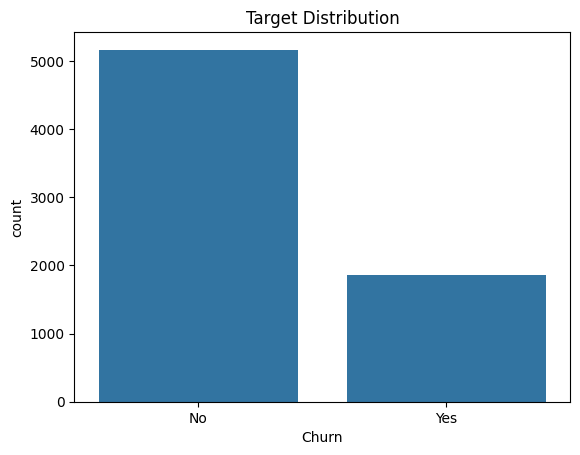

In [ ]:
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title('Target Distribution')
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.to_list()

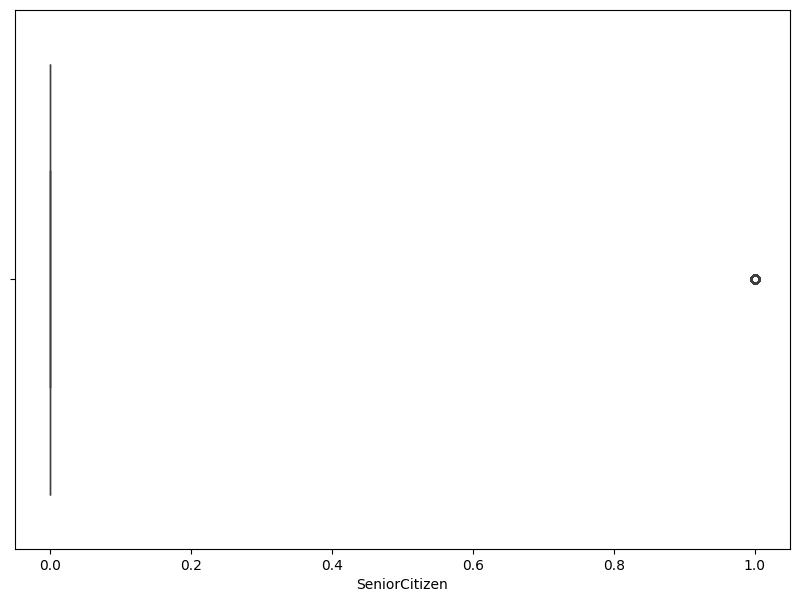

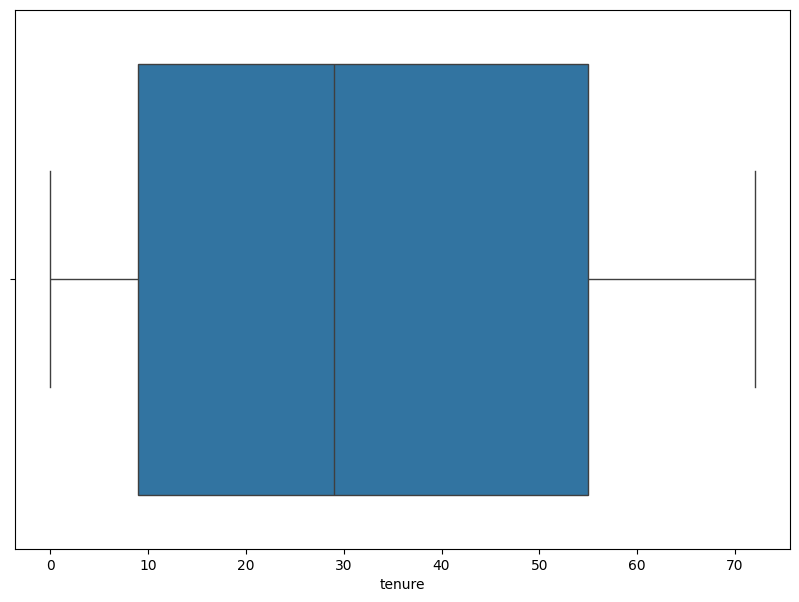

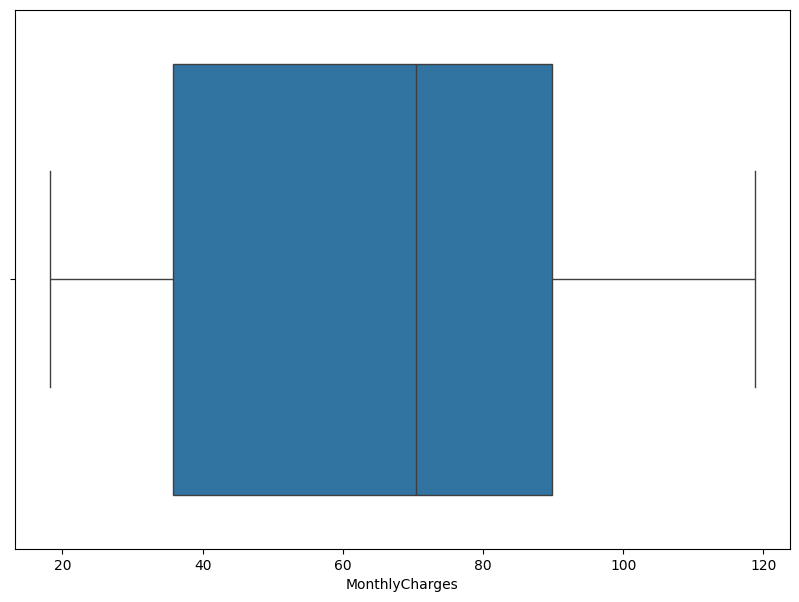

In [ ]:
for col in num_cols:
  plt.figure(figsize=(10 , 7))
  sns.boxplot(x = df[col])
plt.show()

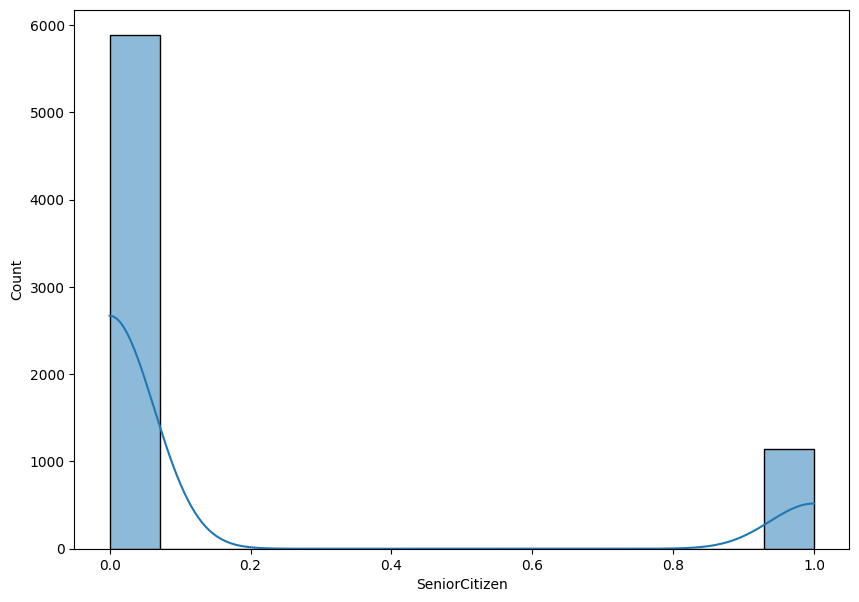

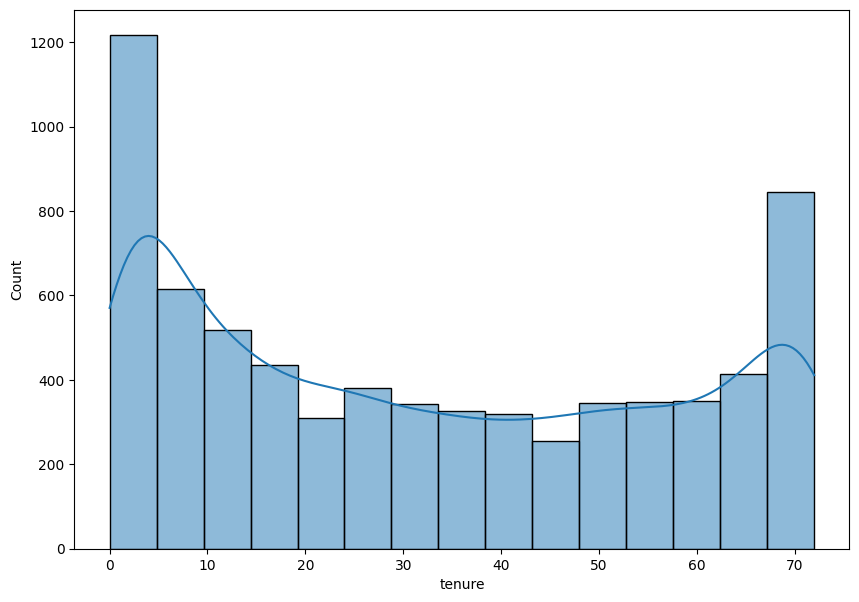

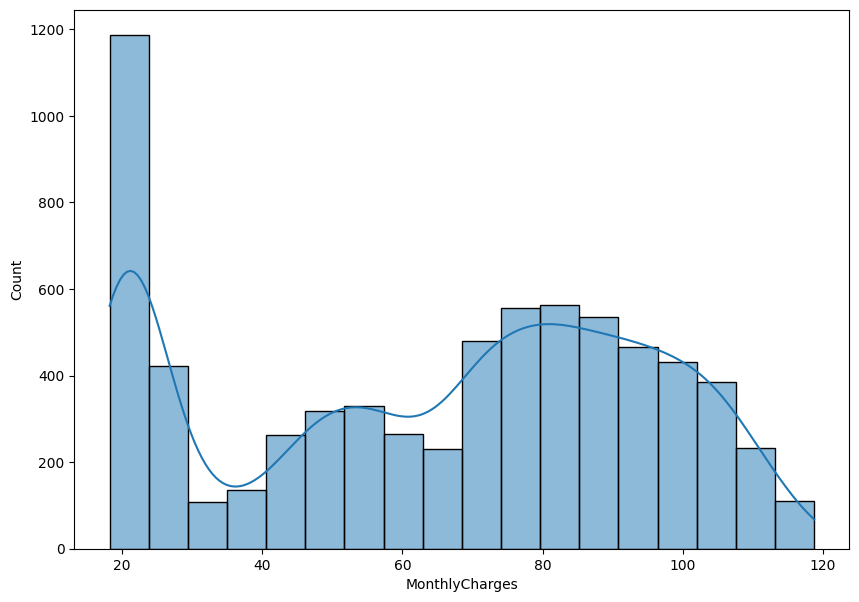

In [ ]:
for col in num_cols:
  plt.figure(figsize=(10 , 7))
  sns.histplot(df[col], kde=True)
plt.show()

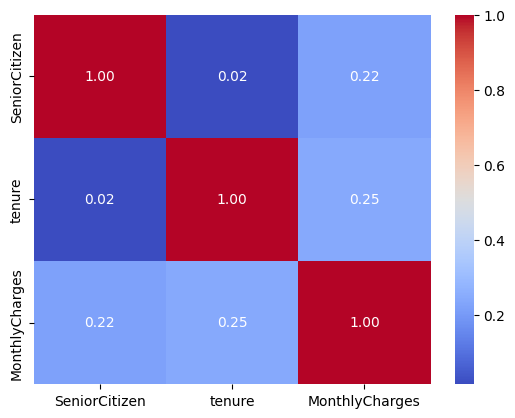

In [ ]:
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_5565/266577964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn'].copy()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
cat_features = X_train.select_dtypes(exclude=[np.number]).columns
num_features = X_train.select_dtypes(include=[np.number]).columns

In [ ]:
num_pipelines = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipelines = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one-hot', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'))
])

transformer = ColumnTransformer([
    ('cat', cat_pipelines, cat_features),
    ('num', num_pipelines , num_features)
])

In [ ]:
X_train_transformer = transformer.fit_transform(X_train)
columns = transformer.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformer, columns=columns)

In [ ]:
X_test_transformer = transformer.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformer, columns=columns)

In [ ]:
import torch

In [ ]:
X_train = torch.FloatTensor(X_train_transformer)
X_test = torch.FloatTensor(X_test_transformer)
y_train_numeric = y_train.map({'No': 0, 'Yes': 1})
y_test_numeric = y_test.map({'No': 0, 'Yes': 1})
y_train = torch.FloatTensor(np.array(y_train_numeric))
y_test = torch.FloatTensor(np.array(y_test_numeric))

In [ ]:
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size= 32, shuffle=True)

In [ ]:
import torch.nn as nn

In [ ]:
class MyModel(nn.Module):
  def __init__(self, n_features, n_outputs=1):
    super().__init__()

    n_outputs = n_outputs if n_outputs > 2 else 1

    self.model = nn.Sequential(
        nn.Linear(n_features, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, n_outputs ),
        nn.ReLU()
    )
  def forward(self, X):
    return self.model(X)

In [ ]:
n_classes = len(np.unique(np.array(y_train)))

In [ ]:
n_features = X_train.shape[1]

In [ ]:
model = MyModel(n_features=n_features, n_outputs=n_classes)

In [ ]:
model

MyModel(
  (model): Sequential(
    (0): Linear(in_features=45, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): ReLU()
  )
)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs, device):
  model.train()
  model.to(device)
  for epoch in  range(n_epochs):
    total_loss = 0.
    for X_batch, y_batch in train_loader:
      X_batch , y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred,y_batch)
      total_loss +=loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f'Epoch: {epoch +1} / {n_epochs}, Loss:{mean_loss}')

In [ ]:
if torch.cuda.is_available:
  device = 'cuda'
elif torch.backends.mps.is_available:
  device = 'mps'
else:
  device = 'cpu'

In [ ]:
train(model, optimizer, criterion, train_loader, 20, device)

Epoch: 1 / 20, Loss:0.6869412901049311
Epoch: 2 / 20, Loss:0.6799531389366497
Epoch: 3 / 20, Loss:0.6777106543833559
Epoch: 4 / 20, Loss:0.677496116947044
Epoch: 5 / 20, Loss:0.6745929762043736
Epoch: 6 / 20, Loss:0.6741939227689396
Epoch: 7 / 20, Loss:0.6738851144909859
Epoch: 8 / 20, Loss:0.6744318885559385
Epoch: 9 / 20, Loss:0.6718377027321946
Epoch: 10 / 20, Loss:0.6712231988256628
Epoch: 11 / 20, Loss:0.6713749725710262
Epoch: 12 / 20, Loss:0.6696792363443158
Epoch: 13 / 20, Loss:0.6693924618038264
Epoch: 14 / 20, Loss:0.669083425605839
Epoch: 15 / 20, Loss:0.6692452986132015
Epoch: 16 / 20, Loss:0.666772110895677
Epoch: 17 / 20, Loss:0.6667945930226282
Epoch: 18 / 20, Loss:0.6669523739679293
Epoch: 19 / 20, Loss:0.6654333536597815
Epoch: 20 / 20, Loss:0.66449203917926
